# Import Libraries and Data Files

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Exploring Data

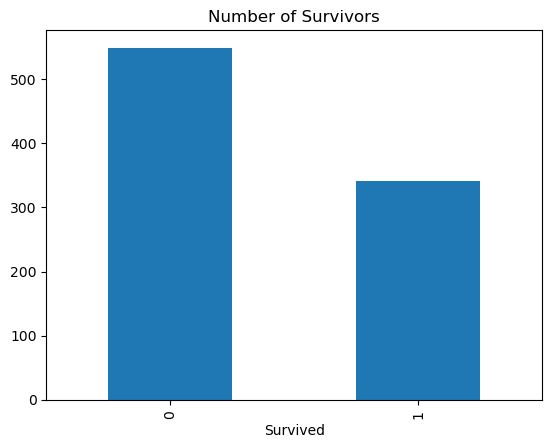

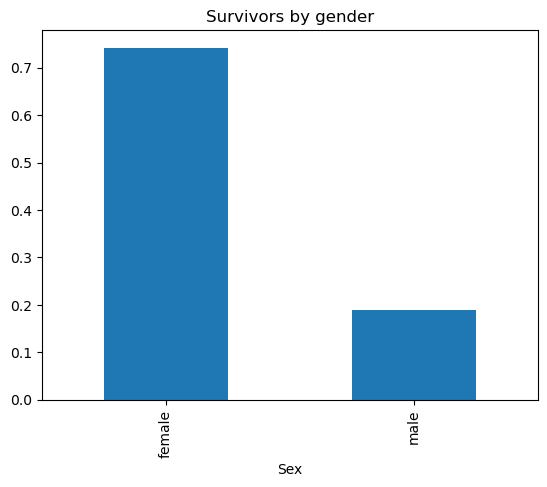

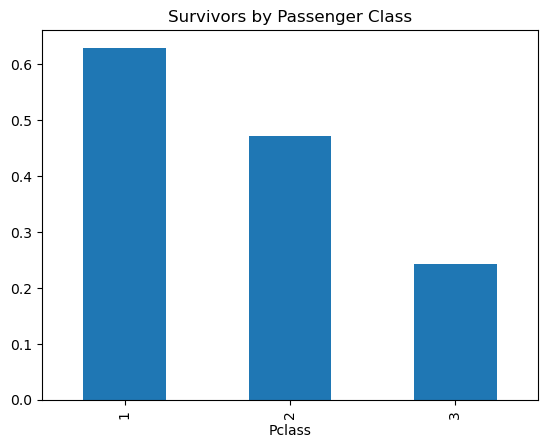

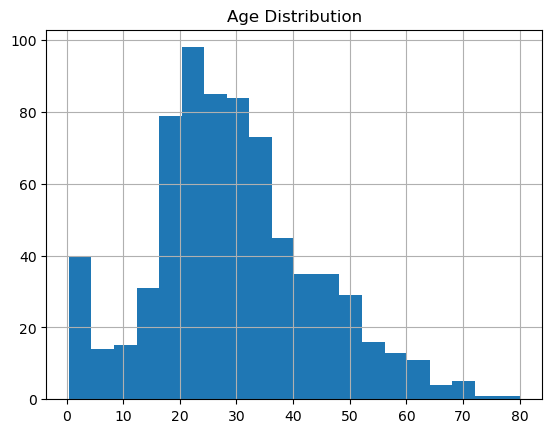

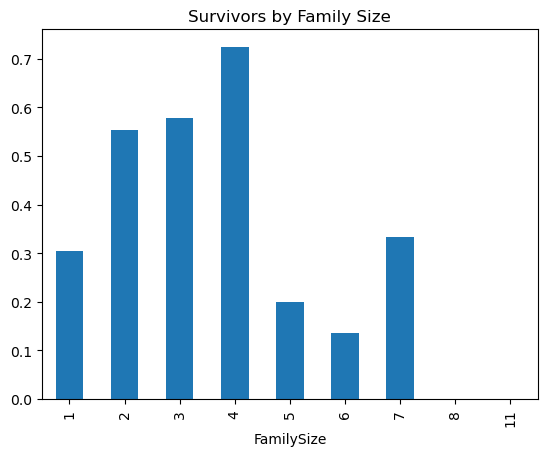

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
dtype: int64

In [24]:
train["Survived"].value_counts().plot(kind="bar")
plt.title("Number of Survivors")
plt.show()
train.groupby("Sex")["Survived"].mean().plot(kind='bar')
plt.title("Survivors by gender")
plt.show()
train.groupby("Pclass")["Survived"].mean().plot(kind='bar')
plt.title("Survivors by Passenger Class")
plt.show()
train["Age"].hist(bins=20)
plt.title("Age Distribution")
plt.show()
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
train.groupby("FamilySize")["Survived"].mean().plot(kind='bar')
plt.title("Survivors by Family Size")
plt.show()
train.isnull().sum()


# Building Model

In [58]:
train["Age"] = train["Age"].fillna(train["Age"].median())
train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])
train["Sex"] = train["Sex"].map({"male": 0, "female": 1})
train["Embarked"] = train["Embarked"].map({"S": 0, "C":1, "Q":2})

features = ["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch", "Embarked"]
x = train[features]
y = train["Survived"]

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=50)
model = RandomForestClassifier(random_state=50)
model.fit(x_train,y_train)

predictions = model.predict(x_val)
accuracy = accuracy_score(y_val, predictions)
print("Acuracy:", accuracy)

importance = pd.Series(model.feature_importances_, index=features)
print(importance)

Acuracy: 0.7947761194029851
Pclass      0.090778
Sex         0.251851
Age         0.255658
Fare        0.279741
SibSp       0.048601
Parch       0.038339
Embarked    0.035031
dtype: float64
